## Array Level Analysis 
This notebook builds a array-level dataset by combining:
- SSUSA observed species at each camera trap array
- IUCN predicted species from species range intersections with the array footprints 
- comparison metrics such as missing species counts and Jaccard similarity


In [ ]:
import pandas as pd
import numpy as np

# Geo libraries
import geopandas as gpd
from shapely.geometry import Point

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

# Optional: cleaner plots
plt.style.use("default")

# Set random seed for reproducibility
RANDOM_STATE = 42

In [ ]:
# Base folder containing SSUSA input data
BASE_SSUSA_PATH = "../../data/ssusa"

# Main cleaned SSUSA dataset used in this analysis
SSUSA_CSV = "cleaned_snapshot_usa_iucn.csv"

# Folder containing processed outputs from earlier steps
OUTPUT_PATH = "../../outputs"

# Cleaned IUCN ranges file
IUCN_DATA = "iucn_ranges_cleaned.geojson"

# Array-level 1 km footprint polygons
ARRAY_FOOTPRINTS = "ssusa_array_footprints_1km.geojson"

# Projected coordinate reference system often used for area/distance work
# Note:
# This constant is defined here for consistency, even if some later cells
# do not directly use it yet.
AEA = "EPSG:5070"

### Read SSUSA, IUCN, and array footprints

In [72]:
# Load SSUSA camera-level dataset (CSV)
# This contains observed species at camera locations
# ------------------------------------------------------------
ssusa = pd.read_csv(f"{BASE_SSUSA_PATH}/{SSUSA_CSV}")

# Quick check
print("SSUSA shape:", ssusa.shape)
ssusa.head()


# ------------------------------------------------------------
# Load IUCN species range polygons
# These represent predicted species distributions
# ------------------------------------------------------------
iucn = gpd.read_file(f"{OUTPUT_PATH}/{IUCN_DATA}")

print("IUCN shape:", iucn.shape)
iucn.head()


# ------------------------------------------------------------
# Load array-level 1 km footprints
# These polygons represent each camera trap array
# ------------------------------------------------------------
array_fp = gpd.read_file(f"{OUTPUT_PATH}/{ARRAY_FOOTPRINTS}")

print("Array footprints shape:", array_fp.shape)
array_fp.head()

/var/folders/dx/fz7lq92d3zz2d72jhk9_rryr0000gn/T/ipykernel_40015/4131990169.py:4: DtypeWarning: Columns (4) have mixed types. Specify dtype option on import or set low_memory=False.
  ssusa = pd.read_csv(f"{BASE_SSUSA_PATH}/{SSUSA_CSV}")


SSUSA shape: (698887, 26)
IUCN shape: (130, 29)
Array footprints shape: (261, 4)


,Camera_Trap_Array,Longitude,Latitude,geometry
0,ARNWR,-75.950200,35.819010,"MULTIPOLYGON (((1787033.172 1604085.916, 17869..."
1,AandM,-97.425708,26.211775,"POLYGON ((-143935.903 351080.803, -144033.92 3..."
2,Abilene,-99.881940,32.231940,"POLYGON ((-365247.465 1024198.242, -365320.178..."
3,AbitaFlats,-89.976600,30.506400,"POLYGON ((577236.305 843108.673, 577157.482 84..."
4,Afognak,-152.238110,58.276180,"MULTIPOLYGON (((-3376275.354 4909772.521, -337..."


### Clean SSUSA and keep needed columns

In [73]:
# We only keep columns needed for:
# - species observations
# - array grouping
# - habitat covariates
# - coordinates (if needed later)

ssusa_small = ssusa[
    [
        "Sci_Name",              # species scientific name
        "Camera_Trap_Array",     # array ID
        "Latitude",
        "Longitude",
        "Habitat",
        "Development_Level",
        "Feature_Type",
        "Survey_Nights"
    ]
].copy()

print("SSUSA reduced shape:", ssusa_small.shape)
ssusa_small.head()

SSUSA reduced shape: (698887, 8)


,Sci_Name,Camera_Trap_Array,Latitude,Longitude,Habitat,Development_Level,Feature_Type,Survey_Nights
0,ursus arctos,Crupi,59.42643,-136.2225,forest,wild,water source,64.0
1,ursus arctos,Crupi,59.42643,-136.2225,forest,wild,water source,64.0
2,ursus arctos,Crupi,59.42643,-136.2225,forest,wild,water source,64.0
3,ursus arctos,Crupi,59.42643,-136.2225,forest,wild,water source,64.0
4,ursus arctos,Crupi,59.42643,-136.2225,forest,wild,water source,64.0


### Summarize survey effort as unique nights at the array level

In [75]:
# We want array-level effort measured as the number of DISTINCT nights
# that at least one camera in the array was active.
#
# We should NOT directly sum Survey_Nights across cameras, because
# multiple cameras in the same array may be active on the same calendar night.
# That would double-count effort.
#
# We also avoid using Start_Date to End_Date directly with date_range(),
# because End_Date is the retrieval date, and it may or may not represent
# a full active night depending on field protocol.
#
# Since the metadata defines Survey_Nights as:
# "Number of nights the camera was active at that site"
# we use:
#     Start_Date + Survey_Nights
# to reconstruct the exact sequence of active nights.

# ------------------------------------------------------------
# Keep only columns needed for effort calculation
# ------------------------------------------------------------
effort_df = ssusa[
    ["Camera_Trap_Array", "Start_Date", "Survey_Nights"]
].copy()

# ------------------------------------------------------------
# Convert types
# ------------------------------------------------------------
effort_df["Start_Date"] = pd.to_datetime(effort_df["Start_Date"], errors="coerce")
effort_df["Survey_Nights"] = pd.to_numeric(effort_df["Survey_Nights"], errors="coerce")

# ------------------------------------------------------------
# Remove rows with missing or invalid values
# ------------------------------------------------------------
effort_df = effort_df.dropna(subset=["Camera_Trap_Array", "Start_Date", "Survey_Nights"]).copy()

# Keep only positive survey-night values
effort_df = effort_df[effort_df["Survey_Nights"] > 0].copy()

# Convert survey nights to integer
effort_df["Survey_Nights"] = effort_df["Survey_Nights"].astype(int)

In [76]:
# Generate all active nights for each record
# Example:
# Start_Date = 2021-06-01, Survey_Nights = 3
# Active nights = 2021-06-01, 2021-06-02, 2021-06-03
# ------------------------------------------------------------
effort_df["active_nights"] = effort_df.apply(
    lambda row: pd.date_range(
        start=row["Start_Date"],
        periods=row["Survey_Nights"],
        freq="D"
    ),
    axis=1
)

# ------------------------------------------------------------
# Expand one row per active night
# ------------------------------------------------------------
effort_long = effort_df.explode("active_nights").copy()

# ------------------------------------------------------------
# Count DISTINCT active nights per array
# This removes overlap among cameras within the same array
# ------------------------------------------------------------
array_effort = (
    effort_long
    .groupby("Camera_Trap_Array")["active_nights"]
    .nunique()
    .reset_index()
    .rename(columns={"active_nights": "unique_nights_array"})
)

print("Number of arrays in effort table:", array_effort.shape[0])
array_effort.head()

Number of arrays in effort table: 261


,Camera_Trap_Array,unique_nights_array
0,ARNWR,112
1,AandM,63
2,Abilene,371
3,AbitaFlats,85
4,Afognak,35


### Create SSUSA observed species at array level

In [77]:
# For each Camera_Trap_Array, we want the list of species
# that were observed in SSUSA.
#
# This will later be compared with IUCN predicted species
# to compute Jaccard similarity at the array level.

# ------------------------------------------------------------
# Keep only columns needed
# ------------------------------------------------------------
ssusa_species = ssusa[
    ["Camera_Trap_Array", "Sci_Name"]
].dropna().copy()

# ------------------------------------------------------------
# Remove duplicate species within the same array
# Example:
# same species detected multiple times in same array
# should count only once
# ------------------------------------------------------------
ssusa_species = ssusa_species.drop_duplicates()

# ------------------------------------------------------------
# Create species set per array
# ------------------------------------------------------------
ssusa_array_species = (
    ssusa_species
    .groupby("Camera_Trap_Array")["Sci_Name"]
    .apply(set)
    .reset_index()
    .rename(columns={"Sci_Name": "ssusa_species"})
)

print("Number of arrays with SSUSA species:", ssusa_array_species.shape[0])
ssusa_array_species.head()

Number of arrays with SSUSA species: 261


,Camera_Trap_Array,ssusa_species
0,ARNWR,"{odocoileus virginianus, didelphis virginiana,..."
1,AandM,"{odocoileus virginianus, didelphis virginiana,..."
2,Abilene,"{odocoileus virginianus, dasypus novemcinctus,..."
3,AbitaFlats,"{odocoileus virginianus, canis latrans, procyo..."
4,Afognak,"{lepus americanus, cervus canadensis, vulpes v..."


### IUCN predicted species using array footprints

In [78]:
# IUCN ranges: keep species name + geometry
# ------------------------------------------------------------
iucn_small = iucn[["sci_name", "geometry"]].copy()

# ------------------------------------------------------------
# Array footprints: keep array ID + geometry
# ------------------------------------------------------------
array_fp_small = array_fp[["Camera_Trap_Array", "geometry"]].copy()

# Quick checks
print("IUCN reduced shape:", iucn_small.shape)
print("Array footprints reduced shape:", array_fp_small.shape)

iucn_small.head()

IUCN reduced shape: (130, 2)
Array footprints reduced shape: (261, 2)


,sci_name,geometry
0,leopardus pardalis,"MULTIPOLYGON (((-1391965.19 1029682.861, -1391..."
1,pecari tajacu,"MULTIPOLYGON (((-1432538.009 1435374.825, -143..."
2,dasypus novemcinctus,"MULTIPOLYGON (((1587947.786 371290.008, 158820..."
3,puma concolor,"MULTIPOLYGON (((-2060713.678 1466026.091, -206..."
4,lasiurus blossevillii,"MULTIPOLYGON (((-2310309.746 1995609.351, -231..."


In [79]:
# Check CRS and make both GeoDataFrames match
# ============================================================

# Spatial joins/intersections only work correctly when both layers
# use the same coordinate reference system (CRS).

print("IUCN CRS:", iucn_small.crs)
print("Array footprint CRS:", array_fp_small.crs)

# If the CRS values are different, reproject one layer so both match.
# Here we reproject IUCN ranges to the CRS of the array footprints.
if iucn_small.crs != array_fp_small.crs:
    iucn_small = iucn_small.to_crs(array_fp_small.crs)

print("\nAfter alignment:")
print("IUCN CRS:", iucn_small.crs)
print("Array footprint CRS:", array_fp_small.crs)

IUCN CRS: EPSG:5070
Array footprint CRS: EPSG:5070

After alignment:
IUCN CRS: EPSG:5070
Array footprint CRS: EPSG:5070


In [81]:
# Spatial join: array footprints intersect IUCN ranges
# If an array footprint overlaps an IUCN range polygon, that species is considered:
# - predicted by IUCN
# - for that Camera_Trap_Array
# ------------------------------------------------------------
array_iucn_join = gpd.sjoin(
    array_fp_small,
    iucn_small,
    how="inner",
    predicate="intersects"
)

print("Spatial join shape:", array_iucn_join.shape)
array_iucn_join.head()

Spatial join shape: (4962, 4)


,Camera_Trap_Array,geometry,index_right,sci_name
0,ARNWR,"MULTIPOLYGON (((1787033.172 1604085.916, 17869...",19,sylvilagus palustris
0,ARNWR,"MULTIPOLYGON (((1787033.172 1604085.916, 17869...",17,urocyon cinereoargenteus
0,ARNWR,"MULTIPOLYGON (((1787033.172 1604085.916, 17869...",26,sciurus niger
0,ARNWR,"MULTIPOLYGON (((1787033.172 1604085.916, 17869...",18,sylvilagus floridanus
0,ARNWR,"MULTIPOLYGON (((1787033.172 1604085.916, 17869...",20,perimyotis subflavus


### Create predicted species set per array

In [82]:
# After the spatial join, each row represents one:
#     array × predicted species
# match
#
# Now we collapse those rows so that each array has a single set
# of all IUCN-predicted species.

# ------------------------------------------------------------
# Keep only array ID and IUCN species name
# ------------------------------------------------------------
array_iucn_small = array_iucn_join[
    ["Camera_Trap_Array", "sci_name"]
].dropna().copy()

# ------------------------------------------------------------
# Remove duplicate array-species pairs
# Example:
# if a species has multiple polygons overlapping the same array,
# it should still count only once for that array
# ------------------------------------------------------------
array_iucn_small = array_iucn_small.drop_duplicates()

# ------------------------------------------------------------
# Create species set per array
# ------------------------------------------------------------
iucn_array_species = (
    array_iucn_small
    .groupby("Camera_Trap_Array")["sci_name"]
    .apply(set)
    .reset_index()
    .rename(columns={"sci_name": "iucn_species"})
)

print("Number of arrays with IUCN predicted species:", iucn_array_species.shape[0])
iucn_array_species.head()

Number of arrays with IUCN predicted species: 256


,Camera_Trap_Array,iucn_species
0,ARNWR,"{sylvilagus palustris, odocoileus virginianus,..."
1,AandM,"{odocoileus virginianus, heteromys irroratus, ..."
2,Abilene,"{odocoileus virginianus, cynomys ludovicianus,..."
3,AbitaFlats,"{dasypus novemcinctus, odocoileus virginianus,..."
4,Afognak,"{ursus arctos, alexandromys oeconomus}"


### Merge array-level pieces into one analysis table

In [83]:

# Goal:
# Build one array-level table containing:
# - SSUSA observed species set
# - IUCN predicted species set
# - unique nights per array
#
# This will be the main table used to compute Jaccard similarity
# and later attach array-level covariates.

# ------------------------------------------------------------
# Start with observed species by array
# ------------------------------------------------------------
array_compare = ssusa_array_species.merge(
    iucn_array_species,
    on="Camera_Trap_Array",
    how="outer"
)

# ------------------------------------------------------------
# Add unique nights per array
# ------------------------------------------------------------
array_compare = array_compare.merge(
    array_effort,
    on="Camera_Trap_Array",
    how="left"
)

print("Merged array-level table shape:", array_compare.shape)
array_compare.head()

Merged array-level table shape: (261, 4)


,Camera_Trap_Array,ssusa_species,iucn_species,unique_nights_array
0,ARNWR,"{odocoileus virginianus, didelphis virginiana,...","{sylvilagus palustris, odocoileus virginianus,...",112
1,AandM,"{odocoileus virginianus, didelphis virginiana,...","{odocoileus virginianus, heteromys irroratus, ...",63
2,Abilene,"{odocoileus virginianus, dasypus novemcinctus,...","{odocoileus virginianus, cynomys ludovicianus,...",371
3,AbitaFlats,"{odocoileus virginianus, canis latrans, procyo...","{dasypus novemcinctus, odocoileus virginianus,...",85
4,Afognak,"{lepus americanus, cervus canadensis, vulpes v...","{ursus arctos, alexandromys oeconomus}",35


In [84]:
# After the outer merge, some arrays may have:
# - SSUSA species but no IUCN species
# - IUCN species but no SSUSA species
#
# In those cases, pandas stores the missing value as NaN.
# But for set operations like intersection / union, we need
# actual Python sets, not NaN.
#
# So we convert:
#     NaN  -->  empty set()

# ------------------------------------------------------------
# Fill missing observed species sets
# ------------------------------------------------------------
array_compare["ssusa_species"] = array_compare["ssusa_species"].apply(
    lambda x: x if isinstance(x, set) else set()
)

# ------------------------------------------------------------
# Fill missing predicted species sets
# ------------------------------------------------------------
array_compare["iucn_species"] = array_compare["iucn_species"].apply(
    lambda x: x if isinstance(x, set) else set()
)

array_compare.head()

,Camera_Trap_Array,ssusa_species,iucn_species,unique_nights_array
0,ARNWR,"{odocoileus virginianus, didelphis virginiana,...","{sylvilagus palustris, odocoileus virginianus,...",112
1,AandM,"{odocoileus virginianus, didelphis virginiana,...","{odocoileus virginianus, heteromys irroratus, ...",63
2,Abilene,"{odocoileus virginianus, dasypus novemcinctus,...","{odocoileus virginianus, cynomys ludovicianus,...",371
3,AbitaFlats,"{odocoileus virginianus, canis latrans, procyo...","{dasypus novemcinctus, odocoileus virginianus,...",85
4,Afognak,"{lepus americanus, cervus canadensis, vulpes v...","{ursus arctos, alexandromys oeconomus}",35


### Compute Jaccard similarity per array

In [85]:
# Jaccard similarity measures overlap between two sets:
#
#     Jaccard = |intersection| / |union|
#
# Here:
# - intersection = species both observed in SSUSA and predicted by IUCN
# - union = all species present in either SSUSA or IUCN for that array
#
# Interpretation:
# - 1.0  -> perfect agreement
# - 0.0  -> no overlap
# - intermediate values -> partial overlap

# ------------------------------------------------------------
# Define a helper function to compute Jaccard for one row
# ------------------------------------------------------------
def jaccard_index(set_a, set_b):
    """
    Compute Jaccard similarity between two Python sets.

    Parameters
    ----------
    set_a : set
        First set of species
    set_b : set
        Second set of species

    Returns
    -------
    float
        Jaccard similarity = intersection size / union size
        Returns np.nan if both sets are empty
    """
    union = set_a | set_b
    intersection = set_a & set_b

    if len(union) == 0:
        return np.nan

    return len(intersection) / len(union)

# ------------------------------------------------------------
# Apply row-wise to compute array-level Jaccard similarity
# ------------------------------------------------------------
array_compare["jaccard_index"] = array_compare.apply(
    lambda row: jaccard_index(row["ssusa_species"], row["iucn_species"]),
    axis=1
)

# Quick look at the result
array_compare[
    ["Camera_Trap_Array", "jaccard_index"]
].head()

,Camera_Trap_Array,jaccard_index
0,ARNWR,0.562500
1,AandM,0.473684
2,Abilene,0.521739
3,AbitaFlats,0.400000
4,Afognak,0.111111


### Add species count summaries per array

In [86]:
# These summary columns make the comparison table easier to interpret.
# For each array, we calculate:
# - how many species were observed in SSUSA
# - how many species were predicted by IUCN
# - how many species are shared by both
# - how many species are in the combined union

# ------------------------------------------------------------
# Number of observed species in SSUSA
# ------------------------------------------------------------
array_compare["n_ssusa_species"] = array_compare["ssusa_species"].apply(len)

# ------------------------------------------------------------
# Number of predicted species in IUCN
# ------------------------------------------------------------
array_compare["n_iucn_species"] = array_compare["iucn_species"].apply(len)

# ------------------------------------------------------------
# Number of shared species (intersection)
# ------------------------------------------------------------
array_compare["n_shared_species"] = array_compare.apply(
    lambda row: len(row["ssusa_species"] & row["iucn_species"]),
    axis=1
)

# ------------------------------------------------------------
# Number of total unique species (union)
# ------------------------------------------------------------
array_compare["n_union_species"] = array_compare.apply(
    lambda row: len(row["ssusa_species"] | row["iucn_species"]),
    axis=1
)

# Quick check
array_compare[
    [
        "Camera_Trap_Array",
        "n_ssusa_species",
        "n_iucn_species",
        "n_shared_species",
        "n_union_species",
        "jaccard_index"
    ]
].head()

,Camera_Trap_Array,n_ssusa_species,n_iucn_species,n_shared_species,n_union_species,jaccard_index
0,ARNWR,10,15,9,16,0.562500
1,AandM,9,19,9,19,0.473684
2,Abilene,14,21,12,23,0.521739
3,AbitaFlats,6,15,6,15,0.400000
4,Afognak,8,2,1,9,0.111111


### Build array-level SSUSA metadata / covariates

In [87]:
# Helper function to compute most common value (mode)
# ------------------------------------------------------------
def most_common(series):
    """
    Return the most frequent non-null value in a series.
    If multiple values tie, returns the first.
    """
    s = series.dropna()

    if len(s) == 0:
        return np.nan

    return s.mode().iloc[0]

In [88]:
# For each array, assign the value that appears most frequently
# across cameras in that array.
#
# This gives a single representative label per array.
# Keep needed columns
# ------------------------------------------------------------
array_meta_raw = ssusa[
    [
        "Camera_Trap_Array",
        "Habitat",
        "Development_Level",
        "Feature_Type",
        "Latitude",
        "Longitude"
    ]
].copy()

# Aggregate to array level
# ------------------------------------------------------------
array_meta = (
    array_meta_raw
    .groupby("Camera_Trap_Array")
    .agg({
        "Habitat": most_common,
        "Development_Level": most_common,
        "Feature_Type": most_common,
        "Latitude": "first",
        "Longitude": "first"
    })
    .reset_index()
    .rename(columns={
        "Habitat": "habitat_array",
        "Development_Level": "development_array",
        "Feature_Type": "feature_array"
    })
)

print("Array metadata shape:", array_meta.shape)
array_meta.head()


Array metadata shape: (261, 6)


,Camera_Trap_Array,habitat_array,development_array,feature_array,Latitude,Longitude
0,ARNWR,wetland,wild,road dirt,35.819010,-75.950200
1,AandM,forest,rural,road dirt,26.211775,-97.425708
2,Abilene,grassland,rural,trail game,32.231940,-99.881940
3,AbitaFlats,forest,wild,NaN,30.506400,-89.976600
4,Afognak,forest,wild,road dirt,58.276180,-152.238110


### Merge array-level metadata into the main analysis table

In [89]:
# Add dominant SSUSA annotation fields to the array-level table:
# - habitat_array
# - development_array
# - feature_array
#
# After this merge, array_compare will contain:
# - observed species
# - predicted species
# - unique nights
# - Jaccard similarity
# - array-level SSUSA covariates

# ------------------------------------------------------------
# Merge metadata into main table
# ------------------------------------------------------------
array_compare = array_compare.merge(
    array_meta,
    on="Camera_Trap_Array",
    how="left"
)

print("Updated array-level table shape:", array_compare.shape)
array_compare.head()

Updated array-level table shape: (261, 14)


,Camera_Trap_Array,ssusa_species,iucn_species,unique_nights_array,jaccard_index,n_ssusa_species,n_iucn_species,n_shared_species,n_union_species,habitat_array,development_array,feature_array,Latitude,Longitude
0,ARNWR,"{odocoileus virginianus, didelphis virginiana,...","{sylvilagus palustris, odocoileus virginianus,...",112,0.562500,10,15,9,16,wetland,wild,road dirt,35.819010,-75.950200
1,AandM,"{odocoileus virginianus, didelphis virginiana,...","{odocoileus virginianus, heteromys irroratus, ...",63,0.473684,9,19,9,19,forest,rural,road dirt,26.211775,-97.425708
2,Abilene,"{odocoileus virginianus, dasypus novemcinctus,...","{odocoileus virginianus, cynomys ludovicianus,...",371,0.521739,14,21,12,23,grassland,rural,trail game,32.231940,-99.881940
3,AbitaFlats,"{odocoileus virginianus, canis latrans, procyo...","{dasypus novemcinctus, odocoileus virginianus,...",85,0.400000,6,15,6,15,forest,wild,NaN,30.506400,-89.976600
4,Afognak,"{lepus americanus, cervus canadensis, vulpes v...","{ursus arctos, alexandromys oeconomus}",35,0.111111,8,2,1,9,forest,wild,road dirt,58.276180,-152.238110


In [90]:
# Check missing values in key analysis columns
# -------------------------------------------------------------
key_cols = [
    "jaccard_index",
    "unique_nights_array",
    "habitat_array",
    "development_array",
    "feature_array",
    "n_ssusa_species",
    "n_iucn_species",
    "n_shared_species",
    "n_union_species"
]

# Count missing values in each key column
missing_summary = array_compare[key_cols].isna().sum().sort_values(ascending=False)

print("Missing values in key columns:")
print(missing_summary)

Missing values in key columns:
feature_array          71
jaccard_index           0
unique_nights_array     0
habitat_array           0
development_array       0
n_ssusa_species         0
n_iucn_species          0
n_shared_species        0
n_union_species         0
dtype: int64


In [91]:
array_compare["feature_array"] = array_compare["feature_array"].fillna("none")

# verify
array_compare["feature_array"].isna().sum()

np.int64(0)

In [93]:
## Save array comparison table to pickle
# Save as pickle (preserves Python objects like sets)
# This is important because we have:
# - ssusa_species (sets)
# - iucn_species (sets)
# Output file name
output_file = f"{OUTPUT_PATH}/array_level_ssusa_iucn_comparison.pkl"

# Save pickle
array_compare.to_pickle(output_file)

print("Saved file to:")
print(output_file)

print("Shape:", array_compare.shape)

Saved file to:
../../outputs/array_level_ssusa_iucn_comparison.pkl
Shape: (261, 14)


### Visualizations 


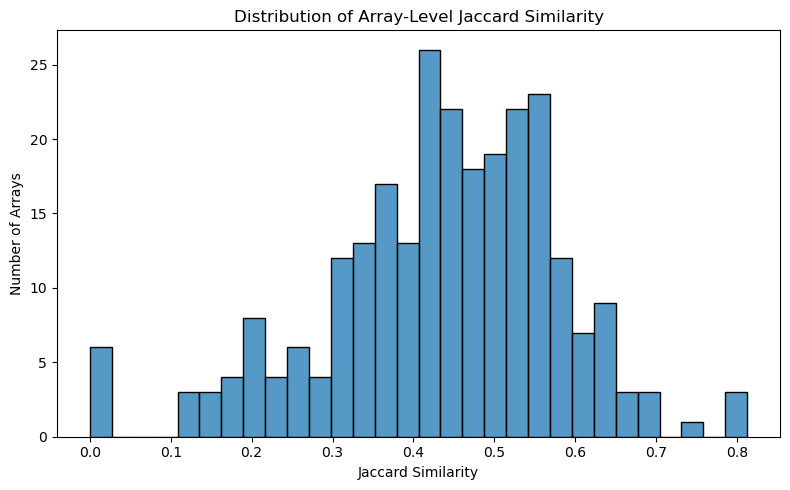

In [102]:
# ------------------------------------------------------------
# Distribution of Jaccard similarity
# ------------------------------------------------------------
import seaborn as sns

plt.figure(figsize=(8,5))

sns.histplot(
    array_compare["jaccard_index"],
    bins=30
)
# plt.hist(array_compare["jaccard_index"], bins=30)
plt.xlabel("Jaccard Similarity")
plt.ylabel("Number of Arrays")
plt.title("Distribution of Array-Level Jaccard Similarity")
plt.tight_layout()
plt.show()






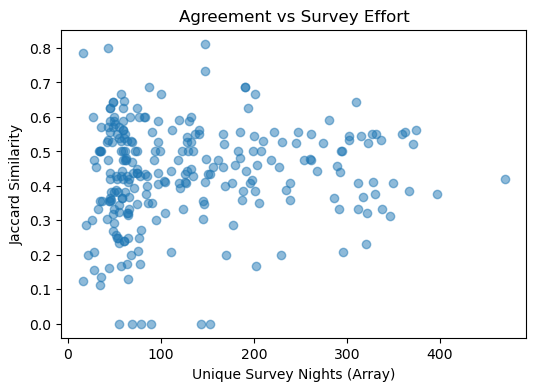

In [95]:
plt.figure(figsize=(6,4))

plt.scatter(
    array_compare["unique_nights_array"],
    array_compare["jaccard_index"],
    alpha=0.5
)

plt.xlabel("Unique Survey Nights (Array)")
plt.ylabel("Jaccard Similarity")
plt.title("Agreement vs Survey Effort")

plt.show()

<Figure size 800x400 with 0 Axes>

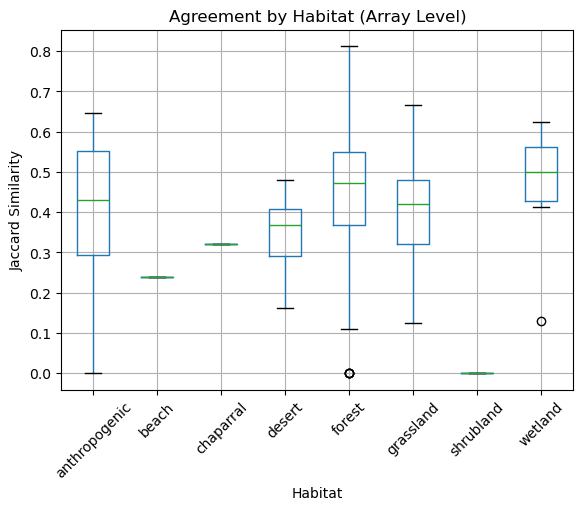

In [96]:
plt.figure(figsize=(8,4))

array_compare.boxplot(
    column="jaccard_index",
    by="habitat_array",
    rot=45
)

plt.title("Agreement by Habitat (Array Level)")
plt.suptitle("")
plt.xlabel("Habitat")
plt.ylabel("Jaccard Similarity")

plt.show()

<Figure size 600x400 with 0 Axes>

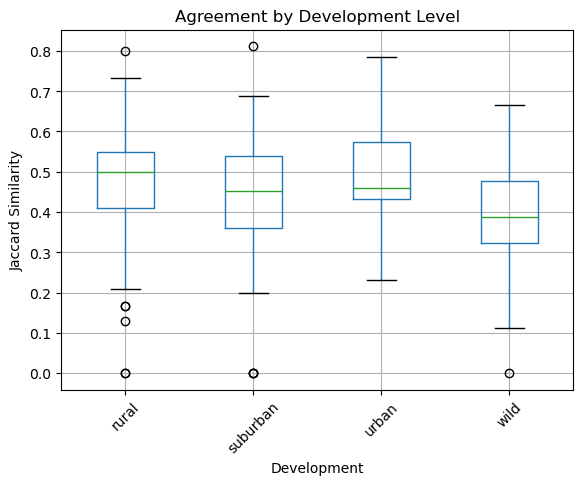

In [97]:
plt.figure(figsize=(6,4))

array_compare.boxplot(
    column="jaccard_index",
    by="development_array",
    rot=45
)

plt.title("Agreement by Development Level")
plt.suptitle("")
plt.xlabel("Development")
plt.ylabel("Jaccard Similarity")

plt.show()

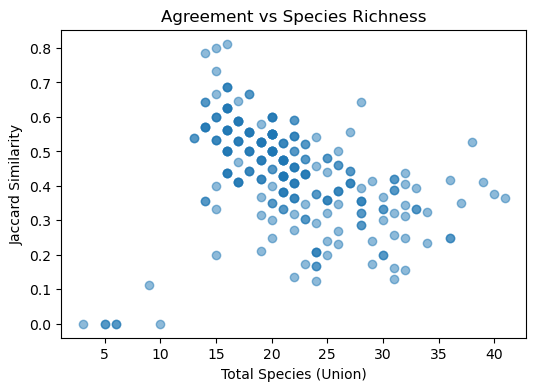

In [98]:
plt.figure(figsize=(6,4))

plt.scatter(
    array_compare["n_union_species"],
    array_compare["jaccard_index"],
    alpha=0.5
)

plt.xlabel("Total Species (Union)")
plt.ylabel("Jaccard Similarity")
plt.title("Agreement vs Species Richness")

plt.show()